In [119]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [120]:
# 設定 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [121]:
#### TODO 讀取紅酒與白酒訓練資料
data_red = pd.read_csv('winequality-red_train.csv', delimiter=',')
data_white = pd.read_csv('winequality-white_train.csv', delimiter=',')
#### TODO
selected_features_red = True
selected_features_white = True
if selected_features_red:
  #### TODO 篩選酒類所需特徵，並進行訓練
  correlation_matrix_red = data_red.corr()
  correlation_matrix_white = data_white.corr()
  quality_corr_red = correlation_matrix_red['quality'].drop('quality')
  quality_corr_white = correlation_matrix_white['quality'].drop('quality')
  top_features_red = quality_corr_red.abs().sort_values(ascending=False).head(7)
  top_features_white = quality_corr_white.abs().sort_values(ascending=False).head(7)
  selected_features_red = top_features_red.index.tolist()
  selected_features_white = top_features_white.index.tolist()
  print("Selected features:", selected_features_red)
  print("Selected features:", selected_features_white)
  #### TODO
if selected_features_red:
  data_red = data_red[selected_features_red + ['quality']]
  data_white = data_white[selected_features_white + ['quality']]

# 分割特徵與標籤
X_red = data_red.iloc[:, :-1].values  # 特徵
X_white = data_white.iloc[:, :-1].values
y_red = data_red.iloc[:, -1].values   # 標籤 (Wine Quality)
y_white = data_white.iloc[:, -1].values

# 標準化數據
scaler_red = StandardScaler()
scaler_white = StandardScaler()
X_red = scaler_red.fit_transform(X_red)
X_white = scaler_white.fit_transform(X_white)


Selected features: ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'total sulfur dioxide', 'chlorides']
Selected features: ['alcohol', 'density', 'chlorides', 'volatile acidity', 'total sulfur dioxide', 'fixed acidity', 'pH']


In [ ]:
# 切分訓練集與測試集
X_temp_red, X_test_red, y_temp_red, y_test_red = train_test_split(X_red, y_red, test_size=0.2, random_state=42)
X_temp_white, X_test_white, y_temp_white, y_test_white = train_test_split(X_white, y_white, test_size=0.2, random_state=42)

X_train_red, X_val_red, y_train_red, y_val_red = train_test_split(X_temp_red, y_temp_red, test_size=0.25, random_state=42)
X_train_white, X_val_white, y_train_white, y_val_white = train_test_split(X_temp_white, y_temp_white, test_size=0.25, random_state=42)

# 轉換為 PyTorch Tensor
X_train_tensor_red = torch.tensor(X_train_red, dtype=torch.float32).to(device)
y_train_tensor_red = torch.tensor(y_train_red, dtype=torch.long).to(device)
X_test_tensor_red = torch.tensor(X_test_red, dtype=torch.float32).to(device)
y_test_tensor_red = torch.tensor(y_test_red, dtype=torch.long).to(device)

X_train_tensor_white = torch.tensor(X_train_white, dtype=torch.float32).to(device)
y_train_tensor_white = torch.tensor(y_train_white, dtype=torch.long).to(device)
X_test_tensor_white = torch.tensor(X_test_white, dtype=torch.float32).to(device)
y_test_tensor_white = torch.tensor(y_test_white, dtype=torch.long).to(device)

# 創建 DataLoader
train_dataset_red = TensorDataset(X_train_tensor_red, y_train_tensor_red)
test_dataset_red = TensorDataset(X_test_tensor_red, y_test_tensor_red)
train_loader_red = DataLoader(train_dataset_red, batch_size=16, shuffle=True)
test_loader_red = DataLoader(test_dataset_red, batch_size=16, shuffle=False)

train_dataset_white = TensorDataset(X_train_tensor_white, y_train_tensor_white)
test_dataset_white = TensorDataset(X_test_tensor_white, y_test_tensor_white)
train_loader_white = DataLoader(train_dataset_white, batch_size=16, shuffle=True)
test_loader_white = DataLoader(test_dataset_white, batch_size=16, shuffle=False)

val_loader_red = DataLoader(TensorDataset(torch.tensor(X_val_red, dtype=torch.float32).to(device), 
                                          torch.tensor(y_val_red, dtype=torch.long).to(device)), batch_size=16)
val_loader_white = DataLoader(TensorDataset(torch.tensor(X_val_white, dtype=torch.float32).to(device), 
                                            torch.tensor(y_val_white, dtype=torch.long).to(device)), batch_size=16)

In [123]:
# 定義神經網絡模型
class WineQualityNN(nn.Module):
    def __init__(self, input_dim):
        super(WineQualityNN, self).__init__()
        #### TODO 類別確認
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(64, 1)  # Wine quality 範圍為 0-10
        #### TODO

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        return self.fc3(x)

In [124]:
# 初始化模型
input_dim_red = X_red.shape[1]
input_dim_white = X_white.shape[1]
model_red = WineQualityNN(input_dim_red).to(device)
model_white = WineQualityNN(input_dim_white).to(device)
criterion = nn.MSELoss()
optimizer_red = optim.Adam(model_red.parameters(), lr=0.01)
optimizer_white = optim.Adam(model_white.parameters(), lr=0.01)
scheduler_red = torch.optim.lr_scheduler.StepLR(optimizer_red, step_size=30, gamma=0.1)
scheduler_white = torch.optim.lr_scheduler.StepLR(optimizer_white, step_size=30, gamma=0.1)

In [ ]:
# 訓練模型
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=100):
    best_val_loss = float('inf')
    patience = 10  # Stop if Val Loss doesn't improve for 10 epochs
    counter = 0
    
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch.float())
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation Phase
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                outputs = model(X_val).squeeze()
                loss = criterion(outputs, y_val.float())
                val_loss += loss.item()
        
        val_loss /= len(val_loader) # Average loss for the epoch
        scheduler.step()
        
        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")


In [126]:
# 測試模型
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch).squeeze()
            predicted = torch.round(outputs)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    print(f"Test Accuracy: {100 * correct / total:.2f}%")

In [127]:
# 執行訓練與測試
train_model(model_red, train_loader_red, val_loader_red, criterion, optimizer_red, scheduler_red, epochs=100)
train_model(model_white, train_loader_white, val_loader_white, criterion, optimizer_white, scheduler_white, epochs=100)
test_model(model_red, test_loader_red)
test_model(model_white, test_loader_white)

Epoch 10 | Train Loss: 0.8040 | Val Loss: 0.4314
Epoch 20 | Train Loss: 0.6528 | Val Loss: 0.4367
Early stopping triggered at epoch 22
Epoch 10 | Train Loss: 0.7813 | Val Loss: 0.6301
Epoch 20 | Train Loss: 0.6734 | Val Loss: 0.6105
Early stopping triggered at epoch 21
Test Accuracy: 58.08%
Test Accuracy: 52.31%


In [128]:
# 預測新數據並保存到同一個 CSV
def predict_and_save_combined(model, selected_features, scaler, files, output_csv):
    results = []
    
    # 1. Perform predictions for all provided files
    for file_path, wine_type in files:
        data = pd.read_csv(file_path, delimiter=',')
        if selected_features:
            data = data[selected_features]
            
        # Ensure you use the same scaler that was fitted on the training data!
        X_new = scaler.transform(data.values)
        X_new_tensor = torch.tensor(X_new, dtype=torch.float32).to(device)

        with torch.no_grad():
            outputs = model(X_new_tensor).squeeze()
            predicted = torch.round(outputs).clamp(0, 10)

        results.extend([
            {'ID': f"{wine_type}_{i+1}", 'quality': int(pred.cpu().numpy())}
            for i, pred in enumerate(predicted)
        ])

    # 2. Check if file exists to determine if we need a header
    file_exists = os.path.isfile(output_csv)
    
    # 3. Save to CSV: 
    # mode='a' = append, header=not file_exists (only write header if file is new)
    results_df = pd.DataFrame(results)
    results_df.to_csv(output_csv, mode='a', index=False, header=not file_exists)
    
    print(f"Predictions successfully {'appended to' if file_exists else 'saved to'} {output_csv}")

In [131]:
# 預測紅酒與白酒品質，合併輸出至單一 CSV
predict_and_save_combined(model_red,
  selected_features_red, scaler_red, 
 [("winequality-red_goal.csv", "red")],
                          "winequality_predictions.csv")
predict_and_save_combined(model_white,
  selected_features_white, scaler_white, 
 [("winequality-white_goal.csv", "white")],
                          "winequality_predictions.csv")

Predictions successfully saved to winequality_predictions.csv
Predictions successfully appended to winequality_predictions.csv


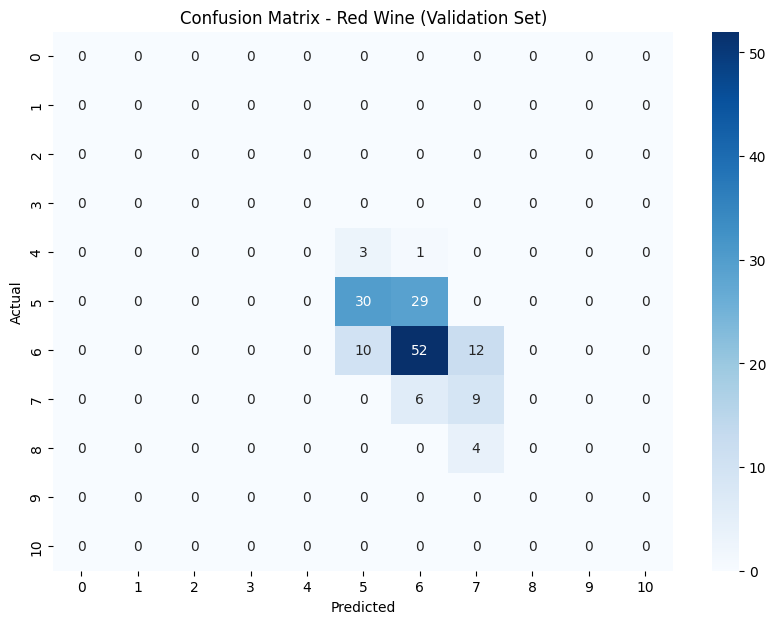

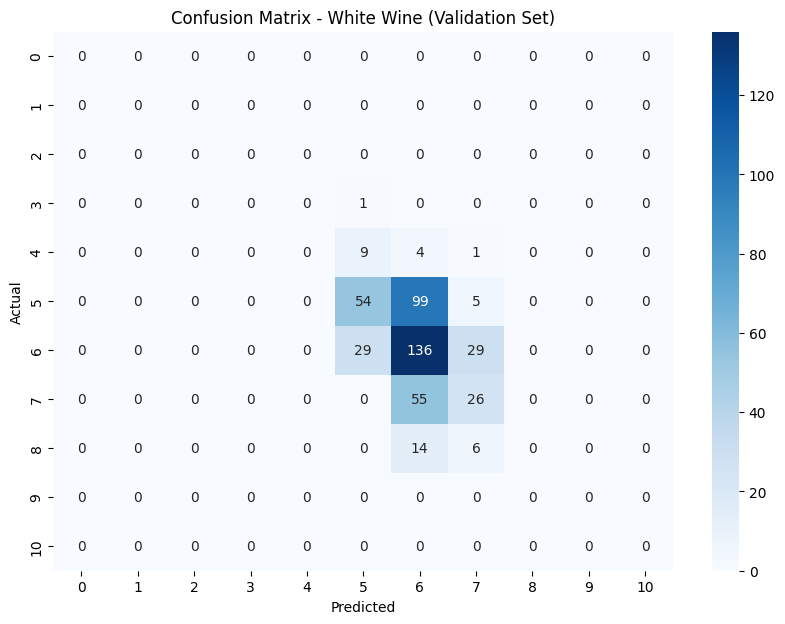

In [132]:
def plot_confusion_matrix(model, loader, device, title):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.round(outputs).cpu().numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
            
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(11)))
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(11), yticklabels=range(11))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {title}')
    plt.show()
    
plot_confusion_matrix(model_red, val_loader_red, device, "Red Wine (Validation Set)")
plot_confusion_matrix(model_white, val_loader_white, device, "White Wine (Validation Set)")